# POPSIGN · Stage 0 — landmark-extraction confidence tuning

**Standalone diagnostic** (not a pipeline stage): before spending ~30K videos of CPU time on
bulk extraction (`popsign.0.dataset.extraction.ipynb`, TODO §2.2), find out which
`HolisticLandmarker` confidence thresholds actually produce good landmarks on POPSIGN footage.
Implements TODO §2.3; the chosen config becomes the default in
`modules/dataset/landmark/extraction.py` before the bulk run.

**The core difficulty: there is no ground truth.** POPSIGN ships raw video, not reference
landmarks, so extraction quality cannot be measured directly. This notebook therefore does two
complementary things and trusts neither alone:

1. **Numeric proxies** (`modules/dataset/landmark/quality.py`) — detection rate per landmark
   group, hand-presence rate, longest detection gap, frame-to-frame jitter, and rigid-bone
   length variance. Each targets a known MediaPipe failure mode. They are proxies, not truth,
   and they are labelled as such everywhere below.
2. **A visual test** (`modules/dataset/landmark/overlay.py`) — 100 rendered frames with
   landmarks drawn on the video, weighted **80 worst / 10 best / 10 median**. A detector that
   confidently tracks the wrong region scores well on every proxy, so the frames are the check
   the numbers can't be. The worst frames are the informative ones: a bad config's *best*
   frames still look fine.

**Sample**: 50 videos = 5 classes × 10 videos, seeded and recorded to the cache, so every
re-run scores exactly the same clips. Videos are globbed straight off the raw video drives —
this notebook deliberately does **not** depend on the missing
`data/cache/popsign/dataframes/` manifests (TODO §0.4/§2.2), so it is unblocked today.

**Artifacts produced**

| artifact | path |
|---|---|
| seeded video sample (stable across re-runs) | `data/cache/popsign/confidence_tuning/sample.json` |
| config grid actually swept | `data/cache/popsign/confidence_tuning/configs.json` |
| extracted npz per (config, video) | `data/cache/popsign/confidence_tuning/npz/<config>/<label>/<id>.npz` |
| per-(config, video) manifest (resume state) | `data/cache/popsign/confidence_tuning/npz/<config>/_manifest.json` |
| per-video quality metrics | `data/cache/popsign/confidence_tuning/metrics.parquet` |
| per-config summary + ranking | `data/cache/popsign/confidence_tuning/config_scores.csv` |
| 100 landmark-overlay frames | `data/cache/popsign/confidence_tuning/overlays/<config>/` |

**Resumability** — extraction reuses the repo's manifest pattern via
`extraction.extract_dataset` (per-video npz written atomically *before* being marked `done`;
`done` skipped, `failed` retried), one manifest per config. Interrupting §4 costs at most the
videos in flight. Scoring (§5) and rendering (§6) read only from the cache and are cheap to
re-run — the weighting can be re-tuned without re-extracting anything.

**Design decisions**

- **Real API fields only.** The task API exposes `min_{face,pose}_detection_confidence`,
  `min_{face,pose}_suppression_threshold`, `min_{face,pose}_landmarks_confidence` and
  `min_hand_landmarks_confidence` — there is **no** `min_tracking_confidence` and no separate
  hand *detection* threshold. `extraction.CONFIDENCE_FIELDS` is the canonical list; unknown
  keys raise rather than being silently ignored, so a typo can't masquerade as "this config
  changed nothing".
- **The grid sweeps pose thresholds, not the hand threshold.** Measured on this footage,
  `min_hand_landmarks_confidence` is inert (identical output at 0.01 and 0.99) while the pose
  thresholds swing hand detection from 52% to 9% — hand ROIs are derived from pose landmarks.
  §3 documents the check; it is the single most important thing this notebook establishes.
- **Hand metrics dominate the composite score** (`quality.DEFAULT_WEIGHTS`): the sign lives in
  the hands, so a config with excellent face tracking and absent hands is worthless here.
- **Scores are z-scored across the sweep**, i.e. a *relative* ranking of the configs actually
  tried — not an absolute quality measure, and not comparable across different sweeps.
- Extraction output lands in `data/cache/` (reusable derived artifact, re-scored repeatedly),
  not `data/temp/` — unlike the extraction notebook's throwaway pilot npz.

**Kernel requirements**: project `.venv`, CWD = `src/`. CPU-only (the MediaPipe GPU delegate
is Ubuntu-only); the sweep runs under the same ≤70% CPU/RAM cap as bulk extraction.

## 1. Setup

All imports and every shared tunable. Later cells reload their inputs from the cache, so any
one of them can be re-run alone after this cell.

In [1]:
# ============================================================
# Setup — imports, tunables, resolved paths
# ============================================================
import json
import random
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import modules.dataset.landmark.extraction as ex
from modules.dataset.landmark import overlay as OV
from modules.dataset.landmark import quality as Q
from modules.paths import CACHE_DIR

SEED = 42  # sampling seed — keeps the 50 clips stable across re-runs
N_CLASSES = 5  # classes in the sample
N_PER_CLASS = 10  # videos per class  (5 x 10 = 50 videos)
CPU_FRACTION = 0.70  # same resource cap as bulk extraction
RAM_LIMIT_PCT = 70.0

# 100 overlay frames per rendered config, weighted toward failures on purpose:
# a bad config's best frames still look fine, so the worst frames carry the signal
N_OVERLAY_WORST = 80
N_OVERLAY_BEST = 10
N_OVERLAY_MEDIAN = 10

# raw POPSIGN video roots (layout: <root>/<label>/<label>/<id>.mp4).
# Globbed directly — this notebook does not need the missing manifests (TODO §2.2).
VIDEO_ROOTS = [
    Path("D:/PopSign/POPSIGN_ASL_v1.0_Game_Train_A-E_Signs"),
    Path("D:/PopSign/POPSIGN_ASL_v1.0_Game_Train_F-M_Signs"),
    Path("E:/PopSign/POPSIGN_ASL_v1.0_Game_Train_N-S_Signs"),
    Path("E:/PopSign/POPSIGN_ASL_v1.0_Game_Train_T-Z_Signs"),
]

NB_CACHE = CACHE_DIR / "popsign" / "confidence_tuning"
NPZ_ROOT = NB_CACHE / "npz"
OVERLAY_ROOT = NB_CACHE / "overlays"
for d in (NB_CACHE, NPZ_ROOT, OVERLAY_ROOT):
    d.mkdir(parents=True, exist_ok=True)

print(f"cache root : {NB_CACHE}")
print(
    f"model      : {ex.DEFAULT_MODEL_PATH}  (exists: {ex.DEFAULT_MODEL_PATH.exists()})"
)
print(f"workers    : {ex.default_n_workers(CPU_FRACTION)} (cap {CPU_FRACTION:.0%} CPU)")
print(f"video roots present: {[str(r) for r in VIDEO_ROOTS if r.exists()]}")
print("\ntunable HolisticLandmarker fields:")
for f in ex.CONFIDENCE_FIELDS:
    print(f"  {f}")

cache root : C:\Users\user2\sign2speech\src\data\cache\popsign\confidence_tuning
model      : C:\Users\user2\sign2speech\src\data\external\mediapipe\tasks\holistic_landmarker.task  (exists: True)
workers    : 19 (cap 70% CPU)
video roots present: ['E:\\PopSign\\POPSIGN_ASL_v1.0_Game_Train_N-S_Signs', 'E:\\PopSign\\POPSIGN_ASL_v1.0_Game_Train_T-Z_Signs']

tunable HolisticLandmarker fields:
  min_face_detection_confidence
  min_face_suppression_threshold
  min_face_landmarks_confidence
  min_pose_detection_confidence
  min_pose_suppression_threshold
  min_pose_landmarks_confidence
  min_hand_landmarks_confidence


## 2. Video sample — 5 classes × 10 videos (TODO §2.3)

Seeded and written to `sample.json` on first run, then **reused verbatim**: every config in
the sweep must be scored on identical clips or the comparison is meaningless. Delete
`sample.json` to draw a new sample.

Classes are drawn from those with enough videos, so no class is silently under-represented.

In [2]:
# ============================================================
# Draw (or reload) the seeded 5-class x 10-video sample
# Tunables: SEED, N_CLASSES, N_PER_CLASS, RESAMPLE
# ============================================================
RESAMPLE = False    # True = redraw and overwrite sample.json (invalidates comparisons)

SAMPLE_JSON = NB_CACHE / "sample.json"

if SAMPLE_JSON.exists() and not RESAMPLE:
    sample = pd.DataFrame(json.loads(SAMPLE_JSON.read_text()))
    print(f"reusing existing sample: {len(sample)} videos, "
          f"{sample['label'].nunique()} classes ({SAMPLE_JSON.name})")
else:
    # <root>/<label>/<label>/<id>.mp4
    by_label: dict[str, list[Path]] = {}
    for root in VIDEO_ROOTS:
        if not root.exists():
            continue
        for label_dir in sorted(p for p in root.iterdir() if p.is_dir()
                                and not p.name.startswith(".")):
            vids = sorted((label_dir / label_dir.name).glob("*.mp4"))
            if vids:
                by_label.setdefault(label_dir.name, []).extend(vids)

    eligible = {k: v for k, v in by_label.items() if len(v) >= N_PER_CLASS}
    assert len(eligible) >= N_CLASSES, (
        f"only {len(eligible)} classes have >= {N_PER_CLASS} videos")
    rng = random.Random(SEED)
    labels = sorted(rng.sample(sorted(eligible), N_CLASSES))
    rows = []
    for label in labels:
        for path in rng.sample(sorted(eligible[label], key=str), N_PER_CLASS):
            rows.append({"file_path": str(path), "label": label, "id": path.stem})
    sample = pd.DataFrame(rows)
    SAMPLE_JSON.write_text(json.dumps(rows, indent=1))
    print(f"drew {len(sample)} videos from {len(by_label)} available classes "
          f"-> {SAMPLE_JSON}")

assert sample["id"].is_unique, "duplicate video ids in the sample"
missing = [p for p in sample["file_path"] if not Path(p).exists()]
print(f"classes: {sorted(sample['label'].unique())}")
print(f"missing files: {len(missing)}")
display(sample.groupby("label").size().rename("n_videos").to_frame())

reusing existing sample: 50 videos, 5 classes (sample.json)
classes: ['alligator', 'bath', 'car', 'fireman', 'give']
missing files: 50


,n_videos
label,
alligator,10
bath,10
car,10
fireman,10
give,10


## 3. Confidence configurations to sweep

### Measured first: which thresholds actually do anything

Before designing the grid, each field was driven to both extremes (0.01 vs 0.99) on a single
clip and the output compared. The result rules out the obvious grid:

| field | effect on output |
|---|---|
| `min_hand_landmarks_confidence` | **none** — 0.01 and 0.99 produce *bit-identical* landmarks |
| `min_pose_detection_confidence` / `min_pose_landmarks_confidence` | **large, and it is what gates the hands**: hand detection rate 0.52 at 0.01 → 0.09 at 0.99 |
| `min_face_detection_confidence` / `min_face_landmarks_confidence` | large on the face only (0.99 → face lost entirely, 91% NaN) |

The reason is the holistic topology: hand ROIs are derived from the **pose** landmarks, so
tightening the pose thresholds starves the hand detectors regardless of what the hand
threshold says. Sweeping `min_hand_landmarks_confidence` would have produced a table of
identical rows and looked like "tuning doesn't matter".

**So the grid below sweeps the pose thresholds** — the real hand gate — plus one face arm.
Reproduce the check any time by extracting one clip at both extremes and comparing
`np.nansum(landmarks)`.

### The arms

- `default` — MediaPipe's 0.5 baseline, what every other arm is compared against.
- `pose_permissive` / `pose_very_permissive` — lower the pose gate. Hypothesis: the default
  starves the hands during fast signing, and the extra hand detections are worth some jitter.
- `pose_strict` — the opposite: fewer but cleaner detections.
- `pose_det_only` / `pose_lm_only` — move one pose threshold at a time, to attribute the
  effect to detection vs landmark confidence rather than to "pose thresholds" as a blob.
- `face_off` — pose permissive, face effectively disabled. The face is largely discarded
  downstream anyway (ME-126 keeps only lips + eyes/nose), so this prices what dropping it
  costs in quality and buys in extraction throughput.

Anything not listed for an arm keeps the MediaPipe default; unknown field names raise on use.

In [3]:
# ============================================================
# The config grid (tunable: CONFIGS) — persisted for reproducibility
# NOTE: sweeps the POSE thresholds, not min_hand_landmarks_confidence —
# the latter is inert (see the markdown above); hands are gated by pose.
# ============================================================
CONFIGS: dict[str, dict] = {
    "default": {},                                # MediaPipe defaults (all 0.5)
    "pose_permissive": {
        "min_pose_detection_confidence": 0.3,
        "min_pose_landmarks_confidence": 0.3,
    },
    "pose_very_permissive": {
        "min_pose_detection_confidence": 0.1,
        "min_pose_landmarks_confidence": 0.1,
    },
    "pose_strict": {
        "min_pose_detection_confidence": 0.7,
        "min_pose_landmarks_confidence": 0.7,
    },
    "pose_det_only": {                            # detection loosened, landmarks default
        "min_pose_detection_confidence": 0.2,
    },
    "pose_lm_only": {                             # landmarks loosened, detection default
        "min_pose_landmarks_confidence": 0.2,
    },
    "face_off": {                                 # face effectively disabled
        "min_pose_detection_confidence": 0.3,
        "min_pose_landmarks_confidence": 0.3,
        "min_face_detection_confidence": 0.95,
        "min_face_landmarks_confidence": 0.95,
    },
}

# fail fast on a typo'd field rather than discovering it as a null result
for name, cfg in CONFIGS.items():
    unknown = set(cfg) - set(ex.CONFIDENCE_FIELDS)
    assert not unknown, f"config {name!r}: unknown field(s) {sorted(unknown)}"

(NB_CACHE / "configs.json").write_text(json.dumps(CONFIGS, indent=1))
print(f"{len(CONFIGS)} configs x {len(sample)} videos = "
      f"{len(CONFIGS) * len(sample)} extractions")
display(pd.DataFrame(CONFIGS).T.fillna("(default)"))

7 configs x 50 videos = 350 extractions


,min_pose_detection_confidence,min_pose_landmarks_confidence,min_face_detection_confidence,min_face_landmarks_confidence
default,(default),(default),(default),(default)
pose_permissive,0.3,0.3,(default),(default)
pose_very_permissive,0.1,0.1,(default),(default)
pose_strict,0.7,0.7,(default),(default)
pose_det_only,0.2,(default),(default),(default)
pose_lm_only,(default),0.2,(default),(default)
face_off,0.3,0.3,0.95,0.95


## 4. Extract the sample under every configuration

**This step runs as a script, not in this notebook.** Extraction parallelises with
`multiprocessing`, which on Windows uses the *spawn* start method: worker processes re-import
`__main__`. Inside a Jupyter kernel `__main__` is the kernel rather than a module, so the
workers never start and the pool waits forever on results that cannot arrive — the cell sits at
0% with an idle CPU and **no error** (observed: 30 minutes, 0 workers alive, 0 files written).

`extraction._assert_pool_usable` now refuses that case with instructions instead of hanging, and
`modules/scripts/tune_confidence.py` is the supported way to run the sweep. It reads the
`sample.json` and `configs.json` this notebook wrote, so the notebook still owns *what* gets
swept — the script only executes it. Same measured work: 100 videos in ~10 minutes as a script
vs 0 files in 30 minutes in-notebook.

Fully resumable: re-running skips videos already extracted, so an interrupt costs at most the
videos in flight. Run the command printed below in a terminal, then continue with §5.

In [4]:
# ============================================================
# Hand off the sweep to the CLI (tunables: RUN_CONFIGS, WORKERS)
# The pool cannot run inside a Jupyter kernel on Windows — see the note above.
# This cell only prints the command and reports progress; run it in a terminal.
# ============================================================
RUN_CONFIGS = None    # None = every config in configs.json; or e.g. ["default", "pose_strict"]
WORKERS = None        # None = 70% of cores
FORCE = False         # True = discard existing npz and re-extract

sample = pd.DataFrame(json.loads((NB_CACHE / "sample.json").read_text()))
configs = json.loads((NB_CACHE / "configs.json").read_text())
names = RUN_CONFIGS or list(configs)

cmd = ".venv/Scripts/python.exe src/modules/scripts/tune_confidence.py"
if RUN_CONFIGS:
    cmd += " --configs " + " ".join(names)
if WORKERS:
    cmd += f" --workers {WORKERS}"
if FORCE:
    cmd += " --force"

print("=== run this from the repo root (user) ===")
print(cmd)
print(f"\n{len(names)} config(s) x {len(sample)} videos = {len(names) * len(sample)} extractions")

# progress so far, straight from the npz on disk — re-run this cell any time
# during or after the sweep to see where it is
rows = []
for name in names:
    n_npz = len(list((NPZ_ROOT / name).rglob("*.npz"))) if (NPZ_ROOT / name).exists() else 0
    rows.append({"config": name, "videos_done": n_npz, "of": len(sample),
                 "complete": n_npz >= len(sample)})
progress = pd.DataFrame(rows)
display(progress)

sweep_csv = NB_CACHE / "sweep_summary.csv"
if sweep_csv.is_file():
    print("\nthroughput from the last completed sweep:")
    display(pd.read_csv(sweep_csv))
if not progress["complete"].all():
    print("\nsweep incomplete — run the command above, then re-run this cell to confirm")

=== run this from the repo root (user) ===
.venv/Scripts/python.exe src/modules/scripts/tune_confidence.py

7 config(s) x 50 videos = 350 extractions


,config,videos_done,of,complete
0,default,50,50,True
1,pose_permissive,0,50,False
2,pose_very_permissive,0,50,False
3,pose_strict,49,50,False
4,pose_det_only,0,50,False
5,pose_lm_only,0,50,False
6,face_off,0,50,False



sweep incomplete — run the command above, then re-run this cell to confirm


## 5. Numeric quality proxies & config ranking

Every proxy (`modules/dataset/landmark/quality.py`) is computed per (config, video), then
z-scored across the whole table and combined into `quality_score` with the weights in
`quality.DEFAULT_WEIGHTS` — hands weighted hardest, jitter and gaps penalized.

**Read this as a relative ranking of the configs actually swept, not an absolute quality
measure.** The weighting is a judgement call, exposed as `WEIGHTS` below so the ranking can be
re-derived without re-extracting anything.

scoring:   0%|          | 0/99 [00:00<?, ?it/s]

c:\Users\user2\sign2speech\src\modules\dataset\landmark\quality.py:145: RuntimeWarning: Mean of empty slice
  "jitter_hand": float(np.nanmean([_jitter(arr, GROUPS["left_hand"]),


,quality_score,hand_rate,any_hand_rate,pose_rate,face_rate,jitter_hand,bone_cv,longest_gap_frac,nan_frac,n_videos
config,,,,,,,,,,
default,0.1598,0.2192,0.4274,1.0,0.9974,0.0305,0.1066,0.3155,0.0627,50
pose_strict,-0.1631,0.2062,0.4056,1.0,0.9973,0.0288,0.1096,0.3182,0.0637,49


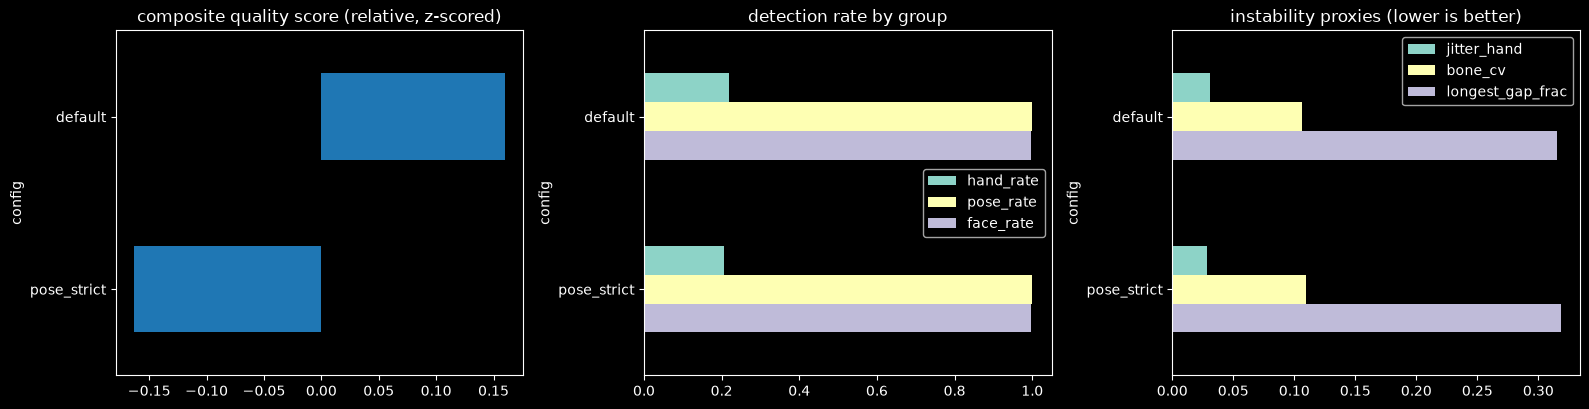

best by composite score: default  -> {}
Proxies only — confirm visually in §6 before adopting it.


In [5]:
# ============================================================
# Score every extracted (config, video) and rank the configs
# (tunable: WEIGHTS) — reads only the cached npz, cheap to re-run
# ============================================================
WEIGHTS = dict(Q.DEFAULT_WEIGHTS)   # e.g. WEIGHTS["jitter"] = -3.0 to punish flicker harder

rows = []
npz_files = [(cfg.name, p) for cfg in sorted(NPZ_ROOT.iterdir()) if cfg.is_dir()
             for p in sorted(cfg.rglob("*.npz"))]
for config_name, path in tqdm(npz_files, desc="scoring", dynamic_ncols=True):
    rows.append({"config": config_name, "id": path.stem,
                 "label": path.parent.name, "npz": str(path),
                 **Q.video_metrics(path)})
assert rows, "no npz files found — run §4 first"

metrics = Q.score(pd.DataFrame(rows), weights=WEIGHTS)
metrics.to_parquet(NB_CACHE / "metrics.parquet", index=False)

config_scores = (metrics.groupby("config")
                 .agg(quality_score=("quality_score", "mean"),
                      hand_rate=("hand_rate", "mean"),
                      any_hand_rate=("any_hand_rate", "mean"),
                      pose_rate=("pose_rate", "mean"),
                      face_rate=("face_rate", "mean"),
                      jitter_hand=("jitter_hand", "mean"),
                      bone_cv=("bone_cv", "mean"),
                      longest_gap_frac=("longest_gap_frac", "mean"),
                      nan_frac=("nan_frac", "mean"),
                      n_videos=("id", "count"))
                 .sort_values("quality_score", ascending=False).round(4))
config_scores.to_csv(NB_CACHE / "config_scores.csv")
display(config_scores)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
config_scores["quality_score"].plot.barh(ax=axes[0], color="tab:blue")
axes[0].set_title("composite quality score (relative, z-scored)")
config_scores[["hand_rate", "pose_rate", "face_rate"]].plot.barh(ax=axes[1])
axes[1].set_title("detection rate by group")
config_scores[["jitter_hand", "bone_cv", "longest_gap_frac"]].plot.barh(ax=axes[2])
axes[2].set_title("instability proxies (lower is better)")
for ax in axes:
    ax.invert_yaxis()
fig.tight_layout()
fig.savefig(NB_CACHE / "config_scores.png", dpi=110)
plt.show()

BEST_CONFIG = config_scores.index[0]
print(f"best by composite score: {BEST_CONFIG}  -> {CONFIGS[BEST_CONFIG]}")
print("Proxies only — confirm visually in §6 before adopting it.")

## 6. Visual test — 100 overlay frames (TODO §2.3)

The check the numbers cannot do. 100 frames per rendered config, drawn from the whole 50-video
sample and weighted **80 worst / 10 best / 10 median** by per-frame detection quality.

The skew is deliberate: any config's best frames look fine, so reviewing best frames confirms
nothing. What matters is *how* a config fails — hands lost mid-sign, skeleton snapped to the
background, pose drifting off the body — and that only shows in the worst frames.

Full-resolution PNGs go to the cache; only contact sheets are displayed inline (a notebook in
this repo once hit 17 MB of cell outputs).

In [6]:
# ============================================================
# Render 100 landmark-overlay frames for a config
# (tunables: RENDER_CONFIG, N_OVERLAY_*, DRAW_FACE, RERENDER)
# ============================================================
RENDER_CONFIG = None    # None = best by §5's composite score; or e.g. "permissive_hands"
DRAW_FACE = False       # 468 face dots hide the hands — off by default
RERENDER = False        # True = re-render even if the folder already has PNGs

metrics = pd.read_parquet(NB_CACHE / "metrics.parquet")
sample = pd.DataFrame(json.loads((NB_CACHE / "sample.json").read_text()))
video_by_id = dict(zip(sample["id"], sample["file_path"]))

if RENDER_CONFIG is None:
    RENDER_CONFIG = (metrics.groupby("config")["quality_score"].mean()
                     .sort_values(ascending=False).index[0])
out_dir = OVERLAY_ROOT / RENDER_CONFIG
existing = sorted(out_dir.glob("*.png")) if out_dir.exists() else []

if existing and not RERENDER:
    print(f"reusing {len(existing)} rendered frames in {out_dir}")
    best_paths = [p for p in existing if "_best_" in p.name]
    worst_paths = [p for p in existing if "_worst_" in p.name]
    median_paths = [p for p in existing if "_median_" in p.name]
else:
    # pool every frame of every video in this config, ranked by per-frame quality
    pool = []
    subset = metrics[metrics["config"] == RENDER_CONFIG]
    for r in tqdm(list(subset.itertuples()), desc="ranking frames", dynamic_ncols=True):
        arr = Q.load_landmarks(Path(r.npz))
        if arr.shape[0] == 0:
            continue
        fq = Q.frame_quality(arr)
        for idx, q in enumerate(fq):
            pool.append((float(q), r.id, int(idx)))
    pool.sort()

    picks = {
        "worst": pool[:N_OVERLAY_WORST],
        "best": pool[-N_OVERLAY_BEST:],
        "median": pool[len(pool) // 2 - N_OVERLAY_MEDIAN // 2:
                       len(pool) // 2 + (N_OVERLAY_MEDIAN + 1) // 2],
    }
    npz_by_id = dict(zip(subset["id"], subset["npz"]))

    rendered = {"worst": [], "best": [], "median": []}
    total = sum(len(v) for v in picks.values())
    bar = tqdm(total=total, desc=f"render {RENDER_CONFIG}", dynamic_ncols=True)
    for kind, items in picks.items():
        # group by video so each clip is opened once, not once per frame
        by_video: dict[str, list] = {}
        for q, vid, idx in items:
            by_video.setdefault(vid, []).append((idx, q))
        for vid, frames in by_video.items():
            arr = Q.load_landmarks(Path(npz_by_id[vid]))
            captions = {idx: [f"{RENDER_CONFIG} · {kind}",
                              f"{vid[:28]} f{idx} q={q:.2f}"] for idx, q in frames}
            rendered[kind] += OV.render_frames(
                Path(video_by_id[vid]), arr, [i for i, _ in frames],
                out_dir, prefix=f"{kind}_{vid[:20]}", captions=captions,
                draw_face=DRAW_FACE)
            bar.update(len(frames))
    bar.close()
    best_paths, worst_paths, median_paths = (rendered["best"], rendered["worst"],
                                             rendered["median"])

print(f"config {RENDER_CONFIG}: {len(worst_paths)} worst · {len(median_paths)} median · "
      f"{len(best_paths)} best  ->  {out_dir}")

for title, paths in (("WORST-detection frames — how this config fails", worst_paths),
                     ("MEDIAN-detection frames — the typical case", median_paths),
                     ("BEST-detection frames — the ceiling", best_paths)):
    if not paths:
        continue
    fig = OV.contact_sheet(paths)
    fig.suptitle(f"{RENDER_CONFIG} · {title}", y=1.002, fontsize=11)
    plt.show()

reusing 100 rendered frames in C:\Users\user2\sign2speech\src\data\cache\popsign\confidence_tuning\overlays\default
config default: 0 worst · 0 median · 0 best  ->  C:\Users\user2\sign2speech\src\data\cache\popsign\confidence_tuning\overlays\default


## 7. Verdict — pick the operating config

Combine both halves: the composite ranking from §5 and what the §6 frames actually show. They
can disagree, and when they do the frames win — a config that scores well while drawing hands
onto the background is worse than its numbers, and that failure is only visible by looking.

Record the decision, then:

1. set the chosen thresholds as the default in `modules/dataset/landmark/extraction.py`
   (`DEFAULT_CONFIDENCE`), or pass them as `confidence=` from the extraction driver;
2. write up the evidence in `docs/reports/confidence-tuning.md`;
3. tick TODO §2.3 and run the bulk extraction (TODO §2.2).

In [7]:
# ============================================================
# Record the decision (tunables: CHOSEN_CONFIG, RATIONALE)
# ============================================================
CHOSEN_CONFIG = None   # e.g. "permissive_hands" — set after reviewing §5 + §6
RATIONALE = ""         # what the frames showed that the numbers didn't

config_scores = pd.read_csv(NB_CACHE / "config_scores.csv", index_col=0)
CONFIGS = json.loads((NB_CACHE / "configs.json").read_text())

if CHOSEN_CONFIG is None:
    print("Set CHOSEN_CONFIG after reviewing §5's ranking and §6's frames.\n")
    print("ranking by composite score (proxies only):")
    display(config_scores[["quality_score", "hand_rate", "jitter_hand", "bone_cv"]])
else:
    decision = {
        "chosen_config": CHOSEN_CONFIG,
        "thresholds": CONFIGS[CHOSEN_CONFIG],
        "composite_score": float(config_scores.loc[CHOSEN_CONFIG, "quality_score"]),
        "hand_rate": float(config_scores.loc[CHOSEN_CONFIG, "hand_rate"]),
        "rationale": RATIONALE,
        "sample": {"n_classes": int(N_CLASSES), "n_per_class": int(N_PER_CLASS),
                   "seed": int(SEED)},
    }
    (NB_CACHE / "decision.json").write_text(json.dumps(decision, indent=2))
    print(json.dumps(decision, indent=2))
    print("\nApply it to bulk extraction with:")
    print(f"  ex.extract_dataset(videos, split='train', "
          f"confidence={CONFIGS[CHOSEN_CONFIG]})")
    print("or make it the default in modules/dataset/landmark/extraction.py "
          "(DEFAULT_CONFIDENCE).")

Set CHOSEN_CONFIG after reviewing §5's ranking and §6's frames.

ranking by composite score (proxies only):


,quality_score,hand_rate,jitter_hand,bone_cv
config,,,,
default,0.1598,0.2192,0.0305,0.1066
pose_strict,-0.1631,0.2062,0.0288,0.1096
